In [22]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import importlib
import sys
from pathlib import Path
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
sys.path.append(str(Path().resolve().parent))
import importlib
import config
importlib.reload(config)
from Bio import SeqIO
import gzip
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Using device: {config.DEVICE}")
print(f"Biopython imported successfully")
print(f"Reference genome exists: {(config.RAW_DIR / 'hg38.fa.gz').exists()}")

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda
Biopython imported successfully
Reference genome exists: True


In [30]:
# Load preprocessed splits
X_train = np.load(config.PROCESSED_DIR / "X_train.npy")
X_val   = np.load(config.PROCESSED_DIR / "X_val.npy")
X_test  = np.load(config.PROCESSED_DIR / "X_test.npy")
y_train = np.load(config.PROCESSED_DIR / "y_train.npy")
y_val   = np.load(config.PROCESSED_DIR / "y_val.npy")
y_test  = np.load(config.PROCESSED_DIR / "y_test.npy")

print(f"Train:      {X_train.shape} | Labels: {np.bincount(y_train)}")
print(f"Validation: {X_val.shape}   | Labels: {np.bincount(y_val)}")
print(f"Test:       {X_test.shape}  | Labels: {np.bincount(y_test)}")

Train:      (239277, 8) | Labels: [196606  42671]
Validation: (34183, 8)   | Labels: [28087  6096]
Test:       (68365, 8)  | Labels: [56173 12192]


In [31]:
class VariantDataset(Dataset):
    """
    PyTorch Dataset for ClinVar SNV variants.
    Takes numpy arrays and returns tensors for model training.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Create datasets
train_dataset = VariantDataset(X_train, y_train)
val_dataset   = VariantDataset(X_val, y_val)
test_dataset  = VariantDataset(X_test, y_test)

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False
)

# Sanity check — peek at one batch
X_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape: {X_batch.shape}")
print(f"Batch y shape: {y_batch.shape}")
print(f"Batch X dtype: {X_batch.dtype}")
print(f"Batch y dtype: {y_batch.dtype}")
print(f"\nExample input: {X_batch[0]}")
print(f"Example label: {y_batch[0]}")

Batch X shape: torch.Size([32, 8])
Batch y shape: torch.Size([32])
Batch X dtype: torch.float32
Batch y dtype: torch.float32

Example input: tensor([0., 1., 0., 0., 0., 0., 0., 1.])
Example label: 0.0


In [15]:
# Compute class weight for positive class (Pathogenic)
n_benign     = np.bincount(y_train)[0]
n_pathogenic = np.bincount(y_train)[1]
pos_weight   = torch.tensor([n_benign / n_pathogenic], dtype=torch.float32).to(config.DEVICE)

print(f"Benign (0):     {n_benign:,}")
print(f"Pathogenic (1): {n_pathogenic:,}")
print(f"pos_weight:     {pos_weight.item():.2f}")

Benign (0):     196,606
Pathogenic (1): 42,671
pos_weight:     4.61


In [16]:
class VariantMLP(nn.Module):
    """
    Baseline MLP for ClinVar SNV pathogenicity classification.
    
    Input: 8-dimensional one-hot encoded variant (ref + alt alleles)
    Output: single logit for binary classification (Pathogenic vs Benign)
    
    Architecture: 3 fully connected layers with ReLU activation and dropout.
    Deliberately simple — establishes baseline before CNN iteration.
    """
    def __init__(self, input_dim=8, hidden_dims=[64, 32], dropout=0.3):
        super(VariantMLP, self).__init__()

        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Layer 2
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Output layer — single logit
            nn.Linear(hidden_dims[1], 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


# Instantiate model and move to device
model = VariantMLP().to(config.DEVICE)

# Loss function with class weighting
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimiser
optimiser = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)

# Print model summary
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model device: {next(model.parameters()).device}")

VariantMLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 2,689
Model device: cuda:0


In [17]:
from sklearn.metrics import roc_auc_score

def train_epoch(model, loader, criterion, optimiser, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimiser.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimiser.step()

        total_loss += loss.item()
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    auc = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item()
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    auc = roc_auc_score(all_labels, all_preds)
    return avg_loss, auc


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


In [18]:
# Training loop
NUM_EPOCHS = config.MAX_EPOCHS
best_val_auc = 0.0
best_model_state = None
history = {'train_loss': [], 'train_auc': [], 'val_loss': [], 'val_auc': []}

print(f"Training for {NUM_EPOCHS} epochs on {config.DEVICE}")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train AUC':>12} {'Val Loss':>10} {'Val AUC':>10}")
print("-" * 56)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_auc = train_epoch(
        model, train_loader, criterion, optimiser, config.DEVICE
    )
    val_loss, val_auc = evaluate(
        model, val_loader, criterion, config.DEVICE
    )

    history['train_loss'].append(train_loss)
    history['train_auc'].append(train_auc)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    # Save best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = model.state_dict().copy()

    # Log every epoch
    print(f"{epoch:>6} {train_loss:>12.4f} {train_auc:>12.4f} {val_loss:>10.4f} {val_auc:>10.4f}")

print("-" * 56)
print(f"Best validation AUC: {best_val_auc:.4f}")

Training for 50 epochs on cuda
 Epoch   Train Loss    Train AUC   Val Loss    Val AUC
--------------------------------------------------------
     1       1.1175       0.5852     1.1139     0.5906
     2       1.1139       0.5922     1.1131     0.5926
     3       1.1139       0.5911     1.1121     0.5913
     4       1.1138       0.5929     1.1116     0.5895
     5       1.1137       0.5924     1.1120     0.5915
     6       1.1130       0.5924     1.1117     0.5897
     7       1.1129       0.5927     1.1117     0.5898
     8       1.1130       0.5914     1.1116     0.5908
     9       1.1129       0.5928     1.1124     0.5921
    10       1.1127       0.5924     1.1112     0.5913
    11       1.1126       0.5931     1.1113     0.5918
    12       1.1124       0.5934     1.1120     0.5919
    13       1.1127       0.5926     1.1111     0.5921
    14       1.1124       0.5919     1.1120     0.5919
    15       1.1119       0.5926     1.1118     0.5919
    16       1.1122       0.5918

Best model saved to D:\projects\claude_code\dissertation\clinvar\outputs\mlp_baseline.pt


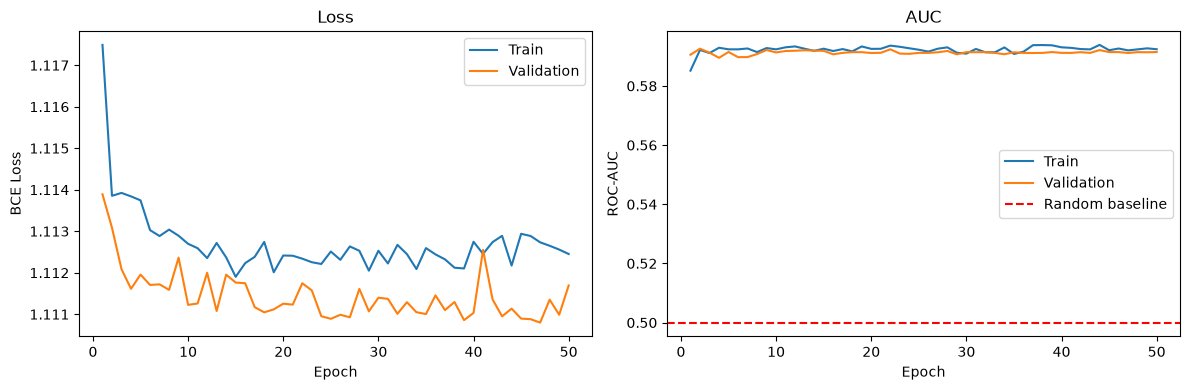

Training curves saved.


In [19]:
# Save best model state
model_path = config.OUTPUTS_DIR / "mlp_baseline.pt"
config.OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
torch.save(best_model_state, model_path)
print(f"Best model saved to {model_path}")

# Plot training curves
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'], label='Validation')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()

ax2.plot(epochs, history['train_auc'], label='Train')
ax2.plot(epochs, history['val_auc'], label='Validation')
ax2.axhline(y=0.5, color='r', linestyle='--', label='Random baseline')
ax2.set_title('AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ROC-AUC')
ax2.legend()

plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "mlp_baseline_training.png", dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")

In [32]:
# Reload the filtered dataset to access gene and chromosome columns
df = pd.read_csv(
    config.PROCESSED_DIR / "clinvar_filtered.tsv.gz",
    sep='\t',
    low_memory=False
)

# Filter to SNVs and drop anomalous rows — same as preprocessing
df_snv = df[df['Type'] == 'single nucleotide variant'].copy()
df_snv = df_snv[df_snv['ReferenceAlleleVCF'].str.len() == 1]
df_snv = df_snv[df_snv['AlternateAlleleVCF'].str.len() == 1]
df_snv = df_snv[df_snv['ReferenceAlleleVCF'] != 'na']
df_snv = df_snv[df_snv['AlternateAlleleVCF'] != 'na']
df_snv = df_snv.reset_index(drop=True)

print(f"Shape: {df_snv.shape}")
print(f"\nUnique chromosomes: {sorted(df_snv['Chromosome'].unique())}")
print(f"\nUnique genes: {df_snv['GeneSymbol'].nunique()}")
print(f"\nTop 30 genes by count:")
print(df_snv['GeneSymbol'].value_counts().head(30))

Shape: (341825, 44)

Unique chromosomes: ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '3', '4', '5', '6', '7', '8', '9', 'MT', 'X', 'Y']

Unique genes: 10045

Top 30 genes by count:
GeneSymbol
TTN        5112
BRCA2      3873
ATM        3417
BRCA1      2693
NF1        2613
APC        2522
TSC2       2480
MSH6       1801
POLE       1696
FBN1       1691
RYR1       1577
RYR2       1514
MSH2       1508
MLH1       1277
SMARCA4    1236
DMD        1223
LDLR       1203
DICER1     1180
BRIP1      1133
PMS2       1132
PALB2      1127
CDH1       1110
POLD1      1070
CFTR       1056
FANCA      1049
PTCH1      1041
MYH7        978
ZNF469      969
TSC1        949
NOTCH1      935
Name: count, dtype: int64


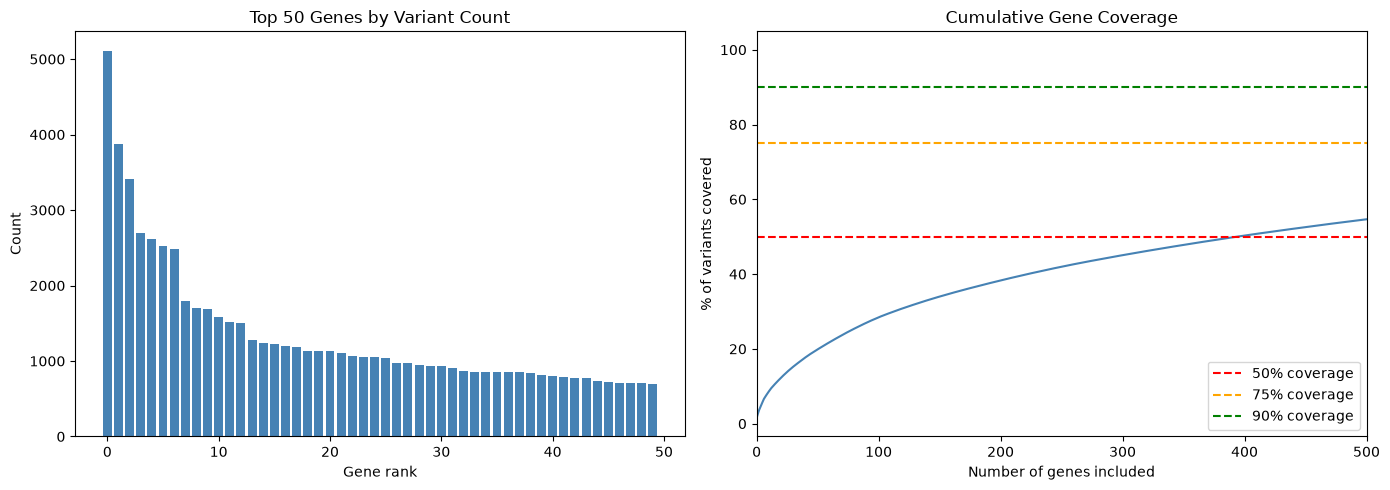

50% of variants covered by top 395 genes
75% of variants covered by top 1299 genes
90% of variants covered by top 2745 genes


In [25]:
import matplotlib.pyplot as plt

gene_counts = df_snv['GeneSymbol'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Top 50 genes
ax1.bar(range(50), gene_counts.values[:50], color='steelblue')
ax1.set_title('Top 50 Genes by Variant Count')
ax1.set_xlabel('Gene rank')
ax1.set_ylabel('Count')

# Cumulative coverage
cumulative = gene_counts.cumsum() / gene_counts.sum() * 100
ax2.plot(range(len(cumulative)), cumulative.values, color='steelblue')
ax2.axhline(y=50, color='r', linestyle='--', label='50% coverage')
ax2.axhline(y=75, color='orange', linestyle='--', label='75% coverage')
ax2.axhline(y=90, color='g', linestyle='--', label='90% coverage')
ax2.set_title('Cumulative Gene Coverage')
ax2.set_xlabel('Number of genes included')
ax2.set_ylabel('% of variants covered')
ax2.legend()
ax2.set_xlim(0, 500)

plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "gene_coverage.png", dpi=150, bbox_inches='tight')
plt.show()

# Find cutoffs
for pct in [50, 75, 90]:
    n_genes = (cumulative < pct).sum() + 1
    print(f"{pct}% of variants covered by top {n_genes} genes")

In [33]:
# Top 50 genes + other bucket
TOP_N_GENES = 50
top_genes = df_snv['GeneSymbol'].value_counts().head(TOP_N_GENES).index.tolist()
gene_to_idx = {gene: i for i, gene in enumerate(top_genes)}
# Index TOP_N_GENES = "other"

# Chromosome encoding
CHROMOSOMES = ['1','2','3','4','5','6','7','8','9','10',
               '11','12','13','14','15','16','17','18','19','20',
               '21','22','X','Y','MT']
chrom_to_idx = {c: i for i, c in enumerate(CHROMOSOMES)}

def encode_enriched(ref, alt, gene, chrom):
    # Allele one-hot (8)
    allele = one_hot_encode(ref) + one_hot_encode(alt)
    
    # Gene one-hot (51: top 50 + other)
    gene_vec = [0] * (TOP_N_GENES + 1)
    gene_vec[gene_to_idx.get(gene, TOP_N_GENES)] = 1
    
    # Chromosome one-hot (25)
    chrom_vec = [0] * len(CHROMOSOMES)
    chrom_idx = chrom_to_idx.get(str(chrom), 0)
    chrom_vec[chrom_idx] = 1
    
    return allele + gene_vec + chrom_vec

# Need one_hot_encode from earlier
NUCLEOTIDES = ['A', 'C', 'G', 'T']
def one_hot_encode(base):
    vector = [0, 0, 0, 0]
    if base in NUCLEOTIDES:
        vector[NUCLEOTIDES.index(base)] = 1
    return vector

# Apply encoding
print("Encoding enriched features...")
X_enriched = np.array([
    encode_enriched(ref, alt, gene, chrom)
    for ref, alt, gene, chrom in zip(
        df_snv['ReferenceAlleleVCF'],
        df_snv['AlternateAlleleVCF'],
        df_snv['GeneSymbol'],
        df_snv['Chromosome']
    )
])
y_enriched = df_snv['Label'].values

print(f"X_enriched shape: {X_enriched.shape}")
print(f"Feature breakdown: 8 allele + 51 gene + 25 chrom = {8+51+25} total")
print(f"\nExample enriched vector length: {len(X_enriched[0])}")

Encoding enriched features...
X_enriched shape: (341825, 84)
Feature breakdown: 8 allele + 51 gene + 25 chrom = 84 total

Example enriched vector length: 84


In [34]:
from sklearn.model_selection import train_test_split

# Stratified split — same proportions as before
X_tr, X_te, y_tr, y_te = train_test_split(
    X_enriched, y_enriched,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_SEED,
    stratify=y_enriched
)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_tr, y_tr,
    test_size=config.VAL_SIZE / (1 - config.TEST_SIZE),
    random_state=config.RANDOM_SEED,
    stratify=y_tr
)

print(f"Train:      {X_tr.shape} | Labels: {np.bincount(y_tr)}")
print(f"Validation: {X_va.shape} | Labels: {np.bincount(y_va)}")
print(f"Test:       {X_te.shape} | Labels: {np.bincount(y_te)}")

# DataLoaders
train_ds = VariantDataset(X_tr, y_tr)
val_ds   = VariantDataset(X_va, y_va)
test_ds  = VariantDataset(X_te, y_te)

train_ld = DataLoader(train_ds, batch_size=config.BATCH_SIZE, shuffle=True)
val_ld   = DataLoader(val_ds,   batch_size=config.BATCH_SIZE, shuffle=False)
test_ld  = DataLoader(test_ds,  batch_size=config.BATCH_SIZE, shuffle=False)

print("\nDataLoaders ready.")

Train:      (239277, 84) | Labels: [196606  42671]
Validation: (34183, 84) | Labels: [28087  6096]
Test:       (68365, 84) | Labels: [56173 12192]

DataLoaders ready.


In [36]:
class EnrichedMLP(nn.Module):
    """
    MLP with enriched features for ClinVar SNV classification.
    
    Input: 84-dimensional vector
        - 8:  one-hot allele (ref + alt)
        - 51: one-hot gene (top 50 + other)
        - 25: one-hot chromosome
    Output: single logit for binary classification

    Wider than baseline MLP to handle richer input.
    Establishes whether gene/chromosome context improves over allele-only.
    Expected to reveal gene-level ascertainment bias as confounder.
    """
    def __init__(self, input_dim=84, hidden_dims=[256, 128, 64], dropout=0.3):
        super(EnrichedMLP, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dims[1], hidden_dims[2]),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dims[2], 1)
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


# Class weight
n_benign     = np.bincount(y_tr)[0]
n_pathogenic = np.bincount(y_tr)[1]
pos_weight   = torch.tensor([n_benign / n_pathogenic], dtype=torch.float32).to(config.DEVICE)

# Instantiate
enriched_model = EnrichedMLP().to(config.DEVICE)
criterion      = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimiser      = torch.optim.Adam(enriched_model.parameters(), lr=config.LEARNING_RATE)

print(enriched_model)
print(f"\nTotal parameters: {sum(p.numel() for p in enriched_model.parameters()):,}")
print(f"Model device: {next(enriched_model.parameters()).device}")

EnrichedMLP(
  (network): Sequential(
    (0): Linear(in_features=84, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 62,977
Model device: cuda:0


In [37]:
NUM_EPOCHS = config.MAX_EPOCHS
best_val_auc = 0.0
best_enriched_state = None
history_enriched = {'train_loss': [], 'train_auc': [], 'val_loss': [], 'val_auc': []}

print(f"Training EnrichedMLP for {NUM_EPOCHS} epochs on {config.DEVICE}")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train AUC':>12} {'Val Loss':>10} {'Val AUC':>10}")
print("-" * 56)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_auc = train_epoch(
        enriched_model, train_ld, criterion, optimiser, config.DEVICE
    )
    val_loss, val_auc = evaluate(
        enriched_model, val_ld, criterion, config.DEVICE
    )
    history_enriched['train_loss'].append(train_loss)
    history_enriched['train_auc'].append(train_auc)
    history_enriched['val_loss'].append(val_loss)
    history_enriched['val_auc'].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_enriched_state = enriched_model.state_dict().copy()

    print(f"{epoch:>6} {train_loss:>12.4f} {train_auc:>12.4f} {val_loss:>10.4f} {val_auc:>10.4f}")

print("-" * 56)
print(f"Best validation AUC: {best_val_auc:.4f}")

# Save immediately after training
torch.save(best_enriched_state, config.OUTPUTS_DIR / "mlp_enriched.pt")
print(f"Enriched model saved.")

Training EnrichedMLP for 50 epochs on cuda
 Epoch   Train Loss    Train AUC   Val Loss    Val AUC
--------------------------------------------------------
     1       1.0655       0.6559     1.0489     0.6716
     2       1.0560       0.6646     1.0511     0.6692
     3       1.0542       0.6673     1.0481     0.6712
     4       1.0529       0.6684     1.0508     0.6707
     5       1.0521       0.6691     1.0480     0.6710
     6       1.0528       0.6684     1.0505     0.6706
     7       1.0527       0.6688     1.0514     0.6699
     8       1.0524       0.6694     1.0493     0.6699
     9       1.0524       0.6688     1.0483     0.6709
    10       1.0520       0.6692     1.0483     0.6705
    11       1.0515       0.6695     1.0494     0.6714
    12       1.0526       0.6692     1.0501     0.6706
    13       1.0529       0.6692     1.0548     0.6702
    14       1.0516       0.6705     1.0507     0.6720
    15       1.0514       0.6704     1.0507     0.6706
    16       1.0514 

In [28]:
# Evaluate enriched model on test set
enriched_model.load_state_dict(best_model_state)
enriched_model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_ld:
        X_batch = X_batch.to(config.DEVICE)
        logits = enriched_model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_preds.extend(probs)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Get gene labels for test set
test_genes = df_snv['GeneSymbol'].values
_, X_te_idx, _, _ = train_test_split(
    np.arange(len(y_enriched)), y_enriched,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_SEED,
    stratify=y_enriched
)
test_gene_labels = test_genes[X_te_idx]

# Split by top-50 vs other
top50_mask = np.array([g in top_genes for g in test_gene_labels])
other_mask  = ~top50_mask

auc_top50 = roc_auc_score(all_labels[top50_mask], all_preds[top50_mask])
auc_other  = roc_auc_score(all_labels[other_mask], all_preds[other_mask])
auc_overall = roc_auc_score(all_labels, all_preds)

print(f"Overall AUC:        {auc_overall:.4f}")
print(f"Top-50 gene AUC:    {auc_top50:.4f}  ({top50_mask.sum():,} variants)")
print(f"'Other' gene AUC:   {auc_other:.4f}  ({other_mask.sum():,} variants)")
print(f"\nAUC gap: {auc_top50 - auc_other:.4f}")

Overall AUC:        0.6693
Top-50 gene AUC:    0.8285  (13,451 variants)
'Other' gene AUC:   0.6127  (54,914 variants)

AUC gap: 0.2158


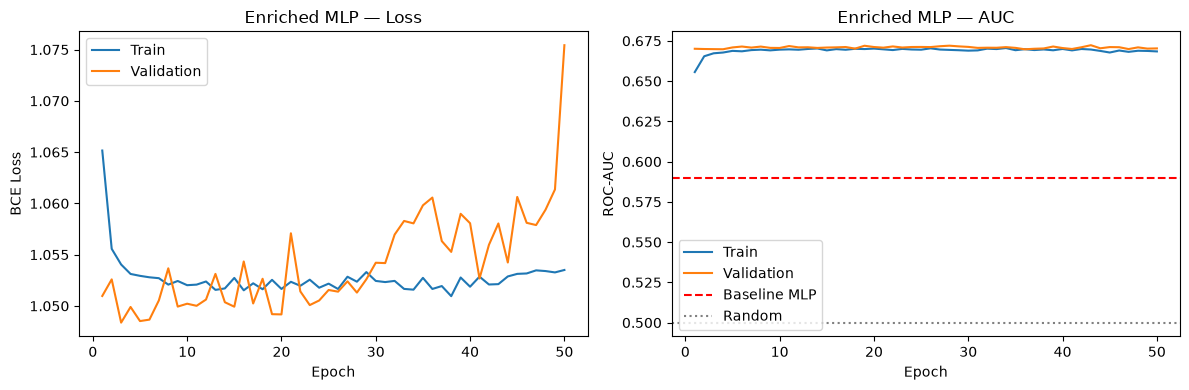

Saved.


In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, history_enriched['train_loss'], label='Train')
ax1.plot(epochs, history_enriched['val_loss'], label='Validation')
ax1.set_title('Enriched MLP — Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()

ax2.plot(epochs, history_enriched['train_auc'], label='Train')
ax2.plot(epochs, history_enriched['val_auc'], label='Validation')
ax2.axhline(y=0.59, color='r', linestyle='--', label='Baseline MLP')
ax2.axhline(y=0.5, color='gray', linestyle=':', label='Random')
ax2.set_title('Enriched MLP — AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ROC-AUC')
ax2.legend()

plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "mlp_enriched_training.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [30]:
# Reload baseline model
baseline_model = VariantMLP().to(config.DEVICE)
baseline_model.load_state_dict(torch.load(config.OUTPUTS_DIR / "mlp_baseline.pt"))
baseline_model.eval()

# Load original splits
X_test_base = np.load(config.PROCESSED_DIR / "X_test.npy")
y_test_base = np.load(config.PROCESSED_DIR / "y_test.npy")

base_dataset = VariantDataset(X_test_base, y_test_base)
base_loader = DataLoader(base_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

all_preds_base, all_labels_base = [], []
with torch.no_grad():
    for X_batch, y_batch in base_loader:
        X_batch = X_batch.to(config.DEVICE)
        logits = baseline_model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_preds_base.extend(probs)
        all_labels_base.extend(y_batch.numpy())

all_preds_base = np.array(all_preds_base)
all_labels_base = np.array(all_labels_base)

# Get test gene labels using same split
_, X_te_idx_base, _, _ = train_test_split(
    np.arange(len(y_enriched)), y_enriched,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_SEED,
    stratify=y_enriched
)
test_gene_labels_base = test_genes[X_te_idx_base]

top50_mask_base = np.array([g in top_genes for g in test_gene_labels_base])
other_mask_base = ~top50_mask_base

auc_top50_base = roc_auc_score(all_labels_base[top50_mask_base], all_preds_base[top50_mask_base])
auc_other_base = roc_auc_score(all_labels_base[other_mask_base], all_preds_base[other_mask_base])
auc_overall_base = roc_auc_score(all_labels_base, all_preds_base)

print("Baseline MLP per-group AUC:")
print(f"Overall AUC:        {auc_overall_base:.4f}")
print(f"Top-50 gene AUC:    {auc_top50_base:.4f}  ({top50_mask_base.sum():,} variants)")
print(f"'Other' gene AUC:   {auc_other_base:.4f}  ({other_mask_base.sum():,} variants)")
print(f"AUC gap:            {auc_top50_base - auc_other_base:.4f}")

Baseline MLP per-group AUC:
Overall AUC:        0.5947
Top-50 gene AUC:    0.6554  (13,451 variants)
'Other' gene AUC:   0.5774  (54,914 variants)
AUC gap:            0.0779


In [2]:
# Load filtered SNV data
df = pd.read_csv(
    config.PROCESSED_DIR / "clinvar_filtered.tsv.gz",
    sep='\t',
    low_memory=False
)

df_snv = df[df['Type'] == 'single nucleotide variant'].copy()
df_snv = df_snv[df_snv['ReferenceAlleleVCF'].str.len() == 1]
df_snv = df_snv[df_snv['AlternateAlleleVCF'].str.len() == 1]
df_snv = df_snv[df_snv['ReferenceAlleleVCF'] != 'na']
df_snv = df_snv[df_snv['AlternateAlleleVCF'] != 'na']
df_snv = df_snv.reset_index(drop=True)

print(f"SNV dataframe: {df_snv.shape}")
print(f"\nColumns we need:")
print(df_snv[['GeneSymbol', 'Chromosome', 'PositionVCF', 
              'ReferenceAlleleVCF', 'AlternateAlleleVCF', 'Label']].head(5))

SNV dataframe: (341825, 44)

Columns we need:
  GeneSymbol Chromosome  PositionVCF ReferenceAlleleVCF AlternateAlleleVCF  \
0    FOXRED1         11    126275389                  C                  T   
1        HFE          6     26092916                  A                  C   
2     ABHD12         20     25302322                  G                  A   
3      HOGA1         10     97611535                  G                  T   
4      HOGA1         10     97598852                  C                  T   

   Label  
0      1  
1      1  
2      1  
3      1  
4      1  


In [3]:
from Bio import SeqIO
import gzip

# Check chromosome naming in our data
print("Chromosome values in SNV data:")
print(sorted(df_snv['Chromosome'].unique()))

Chromosome values in SNV data:
['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '3', '4', '5', '6', '7', '8', '9', 'MT', 'X', 'Y']


In [3]:
from Bio import SeqIO

# Build genome index — creates hg38.fa.idx on disk
# This takes a few minutes but only needs to run once
genome_path = str(config.RAW_DIR / "hg38.fa")
print("Indexing reference genome...")
genome = SeqIO.index(genome_path, "fasta")
print(f"Done. Chromosomes available: {len(genome)}")
print(f"\nFirst 10 chromosome names:")
for i, key in enumerate(list(genome.keys())[:10]):
    print(f"  {key}")

Indexing reference genome...
Done. Chromosomes available: 455

First 10 chromosome names:
  chr1
  chr10
  chr11
  chr11_KI270721v1_random
  chr12
  chr13
  chr14
  chr14_GL000009v2_random
  chr14_GL000225v1_random
  chr14_KI270722v1_random


In [4]:
# Chromosome name mapping
def get_chrom_name(chrom):
    if chrom == 'MT':
        return 'chrM'
    return f"chr{chrom}"

# Flanking sequence extractor
FLANK = 50  # 50 bases either side of variant = 101 bases total

def get_flanking_sequence(genome, chrom, position, flank=FLANK):
    """
    Extract flanking sequence around a variant position.
    Position is 1-based (VCF format) — convert to 0-based for Python slicing.
    Returns a string of length 2*flank+1, or None if out of bounds.
    """
    chrom_name = get_chrom_name(chrom)
    if chrom_name not in genome:
        return None
    
    chrom_seq = genome[chrom_name].seq
    pos_0based = int(position) - 1  # Convert VCF 1-based to 0-based
    
    start = max(0, pos_0based - flank)
    end   = min(len(chrom_seq), pos_0based + flank + 1)
    
    return str(chrom_seq[start:end]).upper()

# Test on first variant
test_row = df_snv.iloc[0]
seq = get_flanking_sequence(genome, test_row['Chromosome'], test_row['PositionVCF'])

print(f"Variant: {test_row['GeneSymbol']} chr{test_row['Chromosome']}:{test_row['PositionVCF']}")
print(f"Ref allele: {test_row['ReferenceAlleleVCF']}")
print(f"Sequence length: {len(seq)}")
print(f"Sequence: {seq}")
print(f"Centre base (should match ref): {seq[FLANK]}")
print(f"Match: {seq[FLANK] == test_row['ReferenceAlleleVCF']}")

Variant: FOXRED1 chr11:126275389
Ref allele: C
Sequence length: 101
Sequence: AAGGTTGGTTTGACCCCTGGTGTCTGCTCCAGGGGCTTCGGCGAAAGGTCCAGTCCTTGGGAGTCCTTTTCTGCCAGGGAGAGGTGACACGTGAGTCTGAG
Centre base (should match ref): C
Match: True


In [5]:
# One-hot encode a DNA sequence
NUCLEOTIDES = ['A', 'C', 'G', 'T']
VOCAB = {n: i for i, n in enumerate(NUCLEOTIDES)}

def encode_sequence(seq, length=2*FLANK+1):
    """
    One-hot encode a DNA sequence into a (length, 4) matrix.
    Unknown bases (N) encoded as all zeros.
    """
    matrix = np.zeros((length, 4), dtype=np.float32)
    for i, base in enumerate(seq[:length]):
        if base in VOCAB:
            matrix[i, VOCAB[base]] = 1.0
    return matrix

# Test encoding
test_seq = get_flanking_sequence(genome, test_row['Chromosome'], test_row['PositionVCF'])
test_encoded = encode_sequence(test_seq)

print(f"Encoded shape: {test_encoded.shape}")
print(f"\nCentre position encoding (ref=C):")
print(f"  {test_encoded[FLANK]}  ← should be [0,1,0,0]")
print(f"\nFirst 5 positions:")
for i in range(5):
    print(f"  pos {i}: {test_seq[i]} → {test_encoded[i]}")

Encoded shape: (101, 4)

Centre position encoding (ref=C):
  [0. 1. 0. 0.]  ← should be [0,1,0,0]

First 5 positions:
  pos 0: A → [1. 0. 0. 0.]
  pos 1: A → [1. 0. 0. 0.]
  pos 2: G → [0. 0. 1. 0.]
  pos 3: G → [0. 0. 1. 0.]
  pos 4: T → [0. 0. 0. 1.]


In [7]:
from pyfaidx import Fasta

# Load genome with pyfaidx — fast random access
print("Loading genome with pyfaidx...")
genome = Fasta(str(config.RAW_DIR / "hg38.fa"))
print(f"Done. {len(genome.keys())} sequences available.")

FLANK = 50
SEQ_LENGTH = 2 * FLANK + 1
NUCLEOTIDES = ['A', 'C', 'G', 'T']
VOCAB = {n: i for i, n in enumerate(NUCLEOTIDES)}

def get_chrom_name(chrom):
    if chrom == 'MT':
        return 'chrM'
    return f"chr{chrom}"

def get_flanking_sequence(chrom, position, flank=FLANK):
    chrom_name = get_chrom_name(chrom)
    if chrom_name not in genome:
        return None
    pos_0based = int(position) - 1
    start = max(0, pos_0based - flank)
    end = pos_0based + flank + 1
    return str(genome[chrom_name][start:end]).upper()

def encode_sequence(seq, length=SEQ_LENGTH):
    matrix = np.zeros((length, 4), dtype=np.float32)
    for i, base in enumerate(seq[:length]):
        if base in VOCAB:
            matrix[i, VOCAB[base]] = 1.0
    return matrix

# Test on first variant
test_row = df_snv.iloc[0]
seq = get_flanking_sequence(test_row['Chromosome'], test_row['PositionVCF'])
print(f"\nTest variant: {test_row['GeneSymbol']} chr{test_row['Chromosome']}:{test_row['PositionVCF']}")
print(f"Sequence length: {len(seq)}")
print(f"Centre base: {seq[FLANK]} (ref: {test_row['ReferenceAlleleVCF']}) Match: {seq[FLANK] == test_row['ReferenceAlleleVCF']}")

Loading genome with pyfaidx...
Done. 455 sequences available.

Test variant: FOXRED1 chr11:126275389
Sequence length: 101
Centre base: C (ref: C) Match: True


In [8]:
print("Extracting flanking sequences for all SNVs...")

X_seq = np.zeros((len(df_snv), SEQ_LENGTH, 4), dtype=np.float32)
failed = 0

for i, row in df_snv.iterrows():
    seq = get_flanking_sequence(row['Chromosome'], row['PositionVCF'])
    if seq is None or len(seq) < SEQ_LENGTH:
        failed += 1
        continue
    X_seq[i] = encode_sequence(seq)

    if i % 50000 == 0:
        print(f"  {i:,} / {len(df_snv):,} processed...")

y_seq = df_snv['Label'].values

print(f"\nDone.")
print(f"X_seq shape: {X_seq.shape}")
print(f"Failed extractions: {failed}")
print(f"Success rate: {(len(df_snv)-failed)/len(df_snv)*100:.2f}%")

Extracting flanking sequences for all SNVs...
  0 / 341,825 processed...
  50,000 / 341,825 processed...
  100,000 / 341,825 processed...
  150,000 / 341,825 processed...
  200,000 / 341,825 processed...
  250,000 / 341,825 processed...
  300,000 / 341,825 processed...

Done.
X_seq shape: (341825, 101, 4)
Failed extractions: 0
Success rate: 100.00%


In [9]:
# Save to processed directory
np.save(config.PROCESSED_DIR / "X_seq.npy", X_seq)
np.save(config.PROCESSED_DIR / "y_seq.npy", y_seq)

size_mb = (config.PROCESSED_DIR / "X_seq.npy").stat().st_size / 1024 / 1024
print(f"X_seq.npy saved — {size_mb:.1f} MB")
print(f"y_seq.npy saved")

X_seq.npy saved — 526.8 MB
y_seq.npy saved


In [10]:
# Stratified split — same proportions as before
X_tr_seq, X_te_seq, y_tr_seq, y_te_seq = train_test_split(
    X_seq, y_seq,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_SEED,
    stratify=y_seq
)

X_tr_seq, X_va_seq, y_tr_seq, y_va_seq = train_test_split(
    X_tr_seq, y_tr_seq,
    test_size=config.VAL_SIZE / (1 - config.TEST_SIZE),
    random_state=config.RANDOM_SEED,
    stratify=y_tr_seq
)

print(f"Train:      {X_tr_seq.shape} | Labels: {np.bincount(y_tr_seq)}")
print(f"Validation: {X_va_seq.shape} | Labels: {np.bincount(y_va_seq)}")
print(f"Test:       {X_te_seq.shape} | Labels: {np.bincount(y_te_seq)}")

# DataLoaders — CNN expects (batch, channels, length) format
# Our data is (batch, length, channels) so we transpose in the Dataset

class SeqDataset(Dataset):
    def __init__(self, X, y):
        # Transpose to (length, 4) → (4, length) for 1D CNN
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_seq_ds = SeqDataset(X_tr_seq, y_tr_seq)
val_seq_ds   = SeqDataset(X_va_seq, y_va_seq)
test_seq_ds  = SeqDataset(X_te_seq, y_te_seq)

train_seq_ld = DataLoader(train_seq_ds, batch_size=config.BATCH_SIZE, shuffle=True)
val_seq_ld   = DataLoader(val_seq_ds,   batch_size=config.BATCH_SIZE, shuffle=False)
test_seq_ld  = DataLoader(test_seq_ds,  batch_size=config.BATCH_SIZE, shuffle=False)

# Sanity check
X_batch, y_batch = next(iter(train_seq_ld))
print(f"\nBatch shape: {X_batch.shape}  ← (batch, channels=4, length=101)")
print(f"Label shape: {y_batch.shape}")

Train:      (239277, 101, 4) | Labels: [196606  42671]
Validation: (34183, 101, 4) | Labels: [28087  6096]
Test:       (68365, 101, 4) | Labels: [56173 12192]

Batch shape: torch.Size([32, 4, 101])  ← (batch, channels=4, length=101)
Label shape: torch.Size([32])


In [11]:
class VariantCNN(nn.Module):
    """
    1D CNN for ClinVar SNV pathogenicity classification.

    Input: (batch, 4, 101) — one-hot encoded flanking sequence
           4 channels (ACGT), 101 positions (50 either side of variant)
    Output: single logit for binary classification

    Architecture: two conv layers to detect local sequence patterns,
    followed by global average pooling and a classification head.
    Learns sequence motifs (splice sites, conserved regions) without
    relying on gene identity — reduces ascertainment bias confounder.
    """
    def __init__(self, dropout=0.3):
        super(VariantCNN, self).__init__()

        # Convolutional layers — learn local sequence motifs
        self.conv_layers = nn.Sequential(
            # Layer 1 — detect short motifs (width 8)
            nn.Conv1d(in_channels=4, out_channels=64, kernel_size=8, padding='same'),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(kernel_size=2),

            # Layer 2 — detect longer patterns (width 8 over pooled sequence)
            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=8, padding='same'),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.MaxPool1d(kernel_size=2),
        )

        # Global average pooling — reduces sequence to fixed size vector
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.global_pool(x).squeeze(-1)
        return self.classifier(x).squeeze(1)


# Class weight
n_benign     = np.bincount(y_tr_seq)[0]
n_pathogenic = np.bincount(y_tr_seq)[1]
pos_weight   = torch.tensor([n_benign / n_pathogenic], dtype=torch.float32).to(config.DEVICE)

# Instantiate
cnn_model = VariantCNN().to(config.DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimiser = torch.optim.Adam(cnn_model.parameters(), lr=config.LEARNING_RATE)

print(cnn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in cnn_model.parameters()):,}")
print(f"Model device: {next(cnn_model.parameters()).device}")

VariantCNN(
  (conv_layers): Sequential(
    (0): Conv1d(4, 64, kernel_size=(8,), stride=(1,), padding=same)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(8,), stride=(1,), padding=same)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 76,097
Model device: cuda:0


In [12]:
def train_epoch(model, loader, criterion, optimiser, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimiser.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimiser.step()
        total_loss += loss.item()
        all_preds.extend(torch.sigmoid(logits).detach().cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
    return total_loss / len(loader), roc_auc_score(all_labels, all_preds)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item()
            all_preds.extend(torch.sigmoid(logits).detach().cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return total_loss / len(loader), roc_auc_score(all_labels, all_preds)


NUM_EPOCHS = config.MAX_EPOCHS
best_val_auc = 0.0
best_model_state = None
history_cnn = {'train_loss': [], 'train_auc': [], 'val_loss': [], 'val_auc': []}

print(f"Training VariantCNN for {NUM_EPOCHS} epochs on {config.DEVICE}")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train AUC':>12} {'Val Loss':>10} {'Val AUC':>10}")
print("-" * 56)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_auc = train_epoch(
        cnn_model, train_seq_ld, criterion, optimiser, config.DEVICE
    )
    val_loss, val_auc = evaluate(
        cnn_model, val_seq_ld, criterion, config.DEVICE
    )

    history_cnn['train_loss'].append(train_loss)
    history_cnn['train_auc'].append(train_auc)
    history_cnn['val_loss'].append(val_loss)
    history_cnn['val_auc'].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = cnn_model.state_dict().copy()

    print(f"{epoch:>6} {train_loss:>12.4f} {train_auc:>12.4f} {val_loss:>10.4f} {val_auc:>10.4f}")

print("-" * 56)
print(f"Best validation AUC: {best_val_auc:.4f}")

Training VariantCNN for 50 epochs on cuda
 Epoch   Train Loss    Train AUC   Val Loss    Val AUC
--------------------------------------------------------


D:\projects\claude_code\dissertation\clinvar\venv\Lib\site-packages\torch\nn\modules\conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Convolution.cpp:1025.)
  return F.conv1d(


     1       1.1263       0.5625     1.1202     0.5982
     2       1.1134       0.5938     1.1032     0.6143
     3       1.1048       0.6110     1.0954     0.6301
     4       1.0956       0.6252     1.0860     0.6416
     5       1.0875       0.6378     1.0818     0.6529
     6       1.0794       0.6482     1.0779     0.6658
     7       1.0699       0.6601     1.0618     0.6730
     8       1.0626       0.6684     1.0613     0.6795
     9       1.0553       0.6757     1.0688     0.6784
    10       1.0505       0.6812     1.0458     0.6894
    11       1.0446       0.6873     1.0471     0.6946
    12       1.0393       0.6921     1.0506     0.6980
    13       1.0340       0.6961     1.0424     0.6986
    14       1.0295       0.7008     1.0428     0.6977
    15       1.0244       0.7057     1.0382     0.7013
    16       1.0219       0.7071     1.0271     0.7078
    17       1.0157       0.7127     1.0299     0.7049
    18       1.0127       0.7162     1.0253     0.7086
    19    

In [13]:
print(f"Continuing CNN training for 50 more epochs...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Train AUC':>12} {'Val Loss':>10} {'Val AUC':>10}")
print("-" * 56)

for epoch in range(51, 101):
    train_loss, train_auc = train_epoch(
        cnn_model, train_seq_ld, criterion, optimiser, config.DEVICE
    )
    val_loss, val_auc = evaluate(
        cnn_model, val_seq_ld, criterion, config.DEVICE
    )

    history_cnn['train_loss'].append(train_loss)
    history_cnn['train_auc'].append(train_auc)
    history_cnn['val_loss'].append(val_loss)
    history_cnn['val_auc'].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_state = cnn_model.state_dict().copy()

    print(f"{epoch:>6} {train_loss:>12.4f} {train_auc:>12.4f} {val_loss:>10.4f} {val_auc:>10.4f}")

print("-" * 56)
print(f"Best validation AUC: {best_val_auc:.4f}")

Continuing CNN training for 50 more epochs...
 Epoch   Train Loss    Train AUC   Val Loss    Val AUC
--------------------------------------------------------
    51       0.9549       0.7589     1.0134     0.7280
    52       0.9526       0.7605     1.0030     0.7302
    53       0.9531       0.7604     0.9989     0.7313
    54       0.9556       0.7585     1.0090     0.7299
    55       0.9511       0.7616     1.0125     0.7288
    56       0.9509       0.7622     1.0142     0.7249
    57       0.9518       0.7615     1.0109     0.7292
    58       0.9488       0.7633     1.0068     0.7315
    59       0.9526       0.7608     1.0171     0.7275
    60       0.9493       0.7631     1.0162     0.7275
    61       0.9450       0.7659     1.0223     0.7274
    62       0.9464       0.7648     1.0103     0.7305


KeyboardInterrupt: 

In [14]:
# Save best CNN model
torch.save(best_model_state, config.OUTPUTS_DIR / "cnn_best.pt")
print(f"Best CNN model saved — Val AUC: {best_val_auc:.4f}")

Best CNN model saved — Val AUC: 0.7315


In [15]:
# Load best model state
cnn_model.load_state_dict(best_model_state)
cnn_model.eval()

# Get predictions on test set
all_preds_cnn, all_labels_cnn = [], []
with torch.no_grad():
    for X_batch, y_batch in test_seq_ld:
        X_batch = X_batch.to(config.DEVICE)
        logits = cnn_model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_preds_cnn.extend(probs)
        all_labels_cnn.extend(y_batch.numpy())

all_preds_cnn  = np.array(all_preds_cnn)
all_labels_cnn = np.array(all_labels_cnn)

# Get gene labels for test set
test_genes = df_snv['GeneSymbol'].values
_, X_te_idx, _, _ = train_test_split(
    np.arange(len(y_seq)), y_seq,
    test_size=config.TEST_SIZE,
    random_state=config.RANDOM_SEED,
    stratify=y_seq
)
test_gene_labels = test_genes[X_te_idx]

# Top 50 genes
top_genes = df_snv['GeneSymbol'].value_counts().head(50).index.tolist()
top50_mask = np.array([g in top_genes for g in test_gene_labels])
other_mask  = ~top50_mask

auc_top50   = roc_auc_score(all_labels_cnn[top50_mask], all_preds_cnn[top50_mask])
auc_other   = roc_auc_score(all_labels_cnn[other_mask], all_preds_cnn[other_mask])
auc_overall = roc_auc_score(all_labels_cnn, all_preds_cnn)

print("CNN per-group AUC:")
print(f"Overall AUC:        {auc_overall:.4f}")
print(f"Top-50 gene AUC:    {auc_top50:.4f}  ({top50_mask.sum():,} variants)")
print(f"'Other' gene AUC:   {auc_other:.4f}  ({other_mask.sum():,} variants)")
print(f"AUC gap:            {auc_top50 - auc_other:.4f}")

CNN per-group AUC:
Overall AUC:        0.7289
Top-50 gene AUC:    0.7157  (13,451 variants)
'Other' gene AUC:   0.7320  (54,914 variants)
AUC gap:            -0.0164


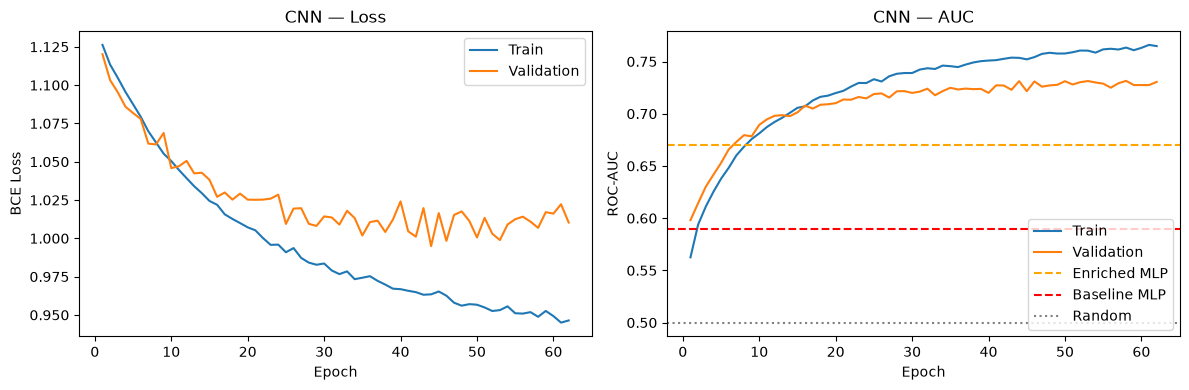

Saved.


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history_cnn['train_loss']) + 1)

ax1.plot(epochs, history_cnn['train_loss'], label='Train')
ax1.plot(epochs, history_cnn['val_loss'], label='Validation')
ax1.set_title('CNN — Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()

ax2.plot(epochs, history_cnn['train_auc'], label='Train')
ax2.plot(epochs, history_cnn['val_auc'], label='Validation')
ax2.axhline(y=0.67, color='orange', linestyle='--', label='Enriched MLP')
ax2.axhline(y=0.59, color='red', linestyle='--', label='Baseline MLP')
ax2.axhline(y=0.5, color='gray', linestyle=':', label='Random')
ax2.set_title('CNN — AUC')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ROC-AUC')
ax2.legend()

plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "cnn_training.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")